                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     5.518
Date:                Fri, 08 May 2026   Prob (F-statistic):           2.01e-08
Time:                        13:22:33   Log-Likelihood:                -1138.5
No. Observations:                 198   AIC:                             2305.
Df Residuals:                     184   BIC:                             2351.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

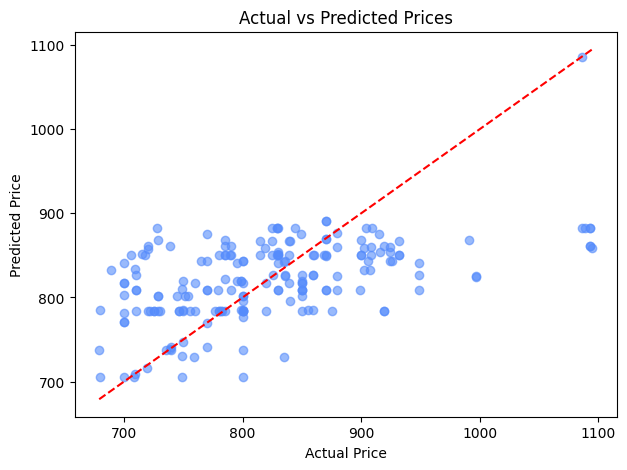

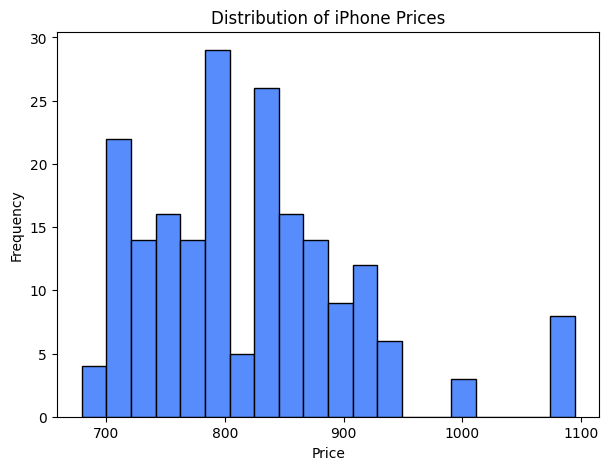

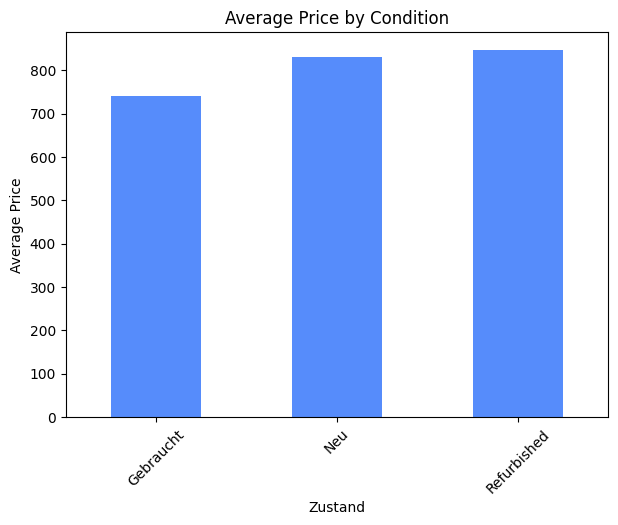

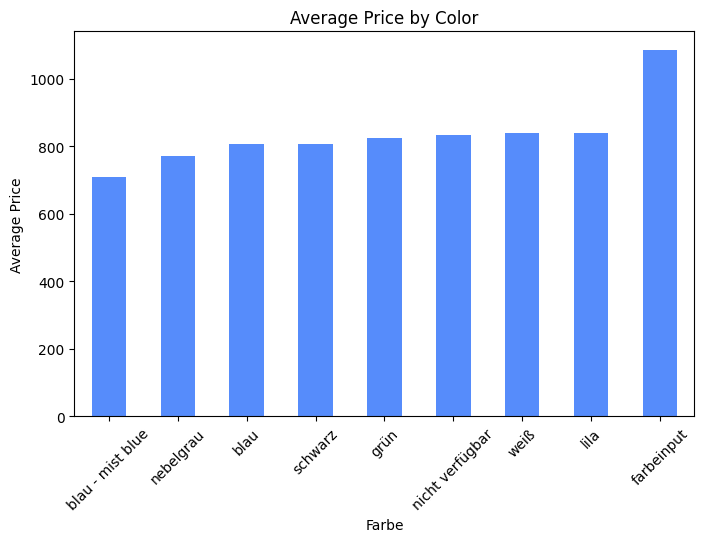

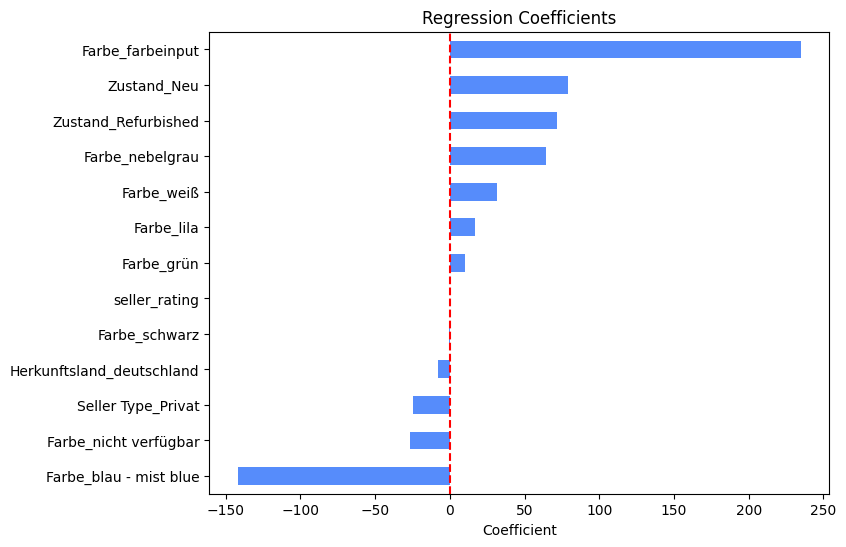

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import statsmodels.api as sm
from color_mapping import clean_color_column
from country_mapping import clean_country_column

file_path = os.path.expanduser("~/Desktop/regge.xlsx")
df = pd.read_excel(file_path)

model_full = df[
    ["Preis", "Zustand", "Farbe", "Seller Rating", "Seller Type", "Herkunftsland"]
].copy()


def clean_price(x):
    if pd.isna(x):
        return np.nan
    x = (
        str(x)
        .replace("EUR", "")
        .replace("€", "")
        .replace(".", "")
        .replace(",", ".")
        .strip()
    )
    try:
        return float(x)
    except:
        return np.nan


def clean_rating(x):
    if pd.isna(x) or x == "N/A":
        return np.nan
    x = str(x).replace("%", "").replace(",", ".").strip()
    try:
        return float(x)
    except:
        return np.nan


model_full["price"] = model_full["Preis"].apply(clean_price)
model_full["seller_rating"] = model_full["Seller Rating"].apply(clean_rating)

model_full["Farbe"] = model_full["Farbe"].astype(str).str.lower().str.strip()

model_full["Farbe"] = clean_color_column(model_full["Farbe"])

model_full["Herkunftsland"] = clean_country_column(model_full["Herkunftsland"])

model_full = model_full.drop(columns=["Preis", "Seller Rating"])
model_full = model_full.dropna()

model_full_encoded = pd.get_dummies(
    model_full,
    columns=["Zustand", "Farbe", "Seller Type", "Herkunftsland"],
    drop_first=True,
)

X = model_full_encoded.drop("price", axis=1)
y = model_full_encoded["price"]

X = X.astype(float)
y = y.astype(float)

X = sm.add_constant(X)

model_B = sm.OLS(y, X).fit()

print(model_B.summary())

print("Observations:", len(y))
print("R²:", model_B.rsquared)
print("Adjusted R²:", model_B.rsquared_adj)

model_full_encoded["predicted_price"] = model_B.predict(X)
model_full_encoded["residual"] = y - model_full_encoded["predicted_price"]


# Visualisierungen
plt.figure(figsize=(7, 5))
plt.scatter(y, model_full_encoded["predicted_price"], alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(y, bins=20, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Distribution of iPhone Prices")
plt.show()
model_full.groupby("Zustand")["price"].mean().sort_values().plot(
    kind="bar", figsize=(7, 5)
)
plt.ylabel("Average Price")
plt.title("Average Price by Condition")
plt.xticks(rotation=45)
plt.show()

model_full.groupby("Farbe")["price"].mean().sort_values().plot(
    kind="bar", figsize=(8, 5)
)
plt.ylabel("Average Price")
plt.title("Average Price by Color")
plt.xticks(rotation=45)
plt.show()

coef = model_B.params.drop("const").sort_values()

plt.figure(figsize=(8, 6))
coef.plot(kind="barh")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Coefficient")
plt.title("Regression Coefficients")
plt.show()